In [6]:
import pandas as pd

rfm = pd.read_csv("../data/rfm_clustered.csv", index_col="Customer ID")
print(f"客户数：{len(rfm):,}")
print(f"\nRFM 用户标签分布：")
print(rfm["用户标签"].value_counts())

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

客户数：5,878

RFM 用户标签分布：
用户标签
沉睡客户        1523
高价值忠诚客户     1300
一般客户        1102
潜力客户         975
新客户          443
流失风险高价值      227
高频低消客户       182
流失风险一般价值     126
Name: count, dtype: int64


# 产品策略建议：基于用户分层的差异化运营方案

> 核心逻辑：不同价值的用户，用不同的策略对待。资源有限，优先投入 ROI 最高的群体。

In [2]:
strategy_base = rfm.groupby("用户标签").agg(
    人数=("Recency", "size"),
    平均最近购买天数=("Recency", "mean"),
    平均购买频次=("Frequency", "mean"),
    平均消费额=("Monetary", "mean"),
    总收入=("Monetary", "sum")
).round(1)

strategy_base["人均收入贡献"] = (strategy_base["总收入"] / strategy_base["总收入"].sum() * 100).round(1)
strategy_base = strategy_base.sort_values("总收入", ascending=False)
print(strategy_base)

            人数  平均最近购买天数  平均购买频次   平均消费额         总收入  人均收入贡献
用户标签                                                        
高价值忠诚客户   1300      20.0    17.1  9329.3  12128115.6    68.4
潜力客户       975      81.5     6.0  2512.1   2449266.0    13.8
流失风险高价值    227     340.7     8.9  4488.4   1018866.7     5.7
一般客户      1102     218.1     2.4   737.8    813033.1     4.6
沉睡客户      1523     459.3     1.3   438.0    667121.9     3.8
新客户        443      28.1     1.5   890.8    394638.6     2.2
高频低消客户     182      23.2     5.4   906.7    165023.1     0.9
流失风险一般价值   126     350.6     5.1   852.1    107364.2     0.6


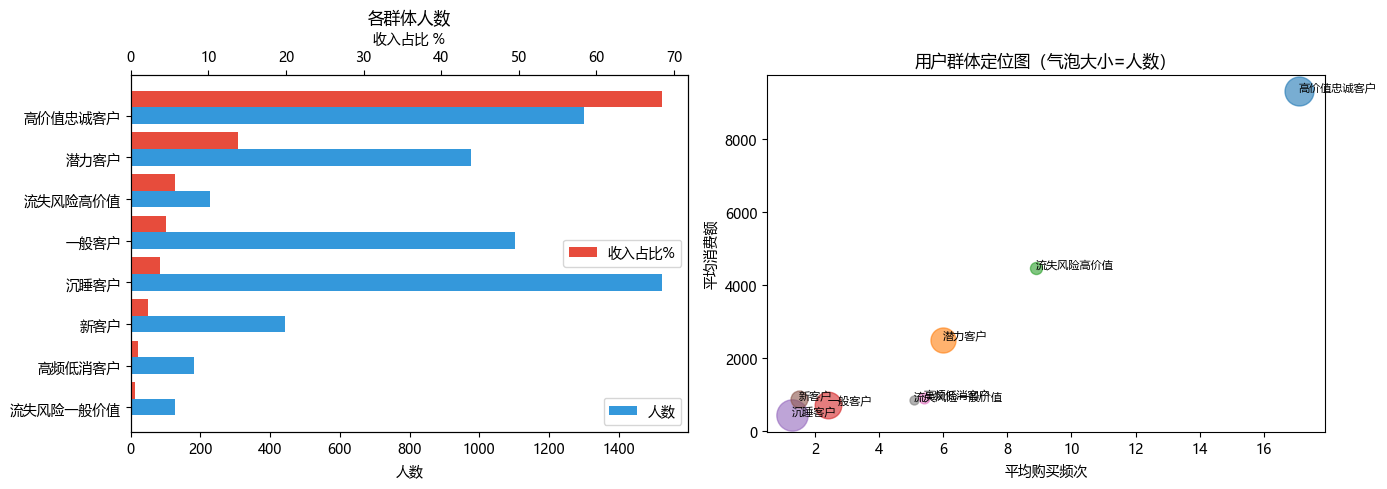

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按总收入排序
sb = strategy_base.sort_values("总收入", ascending=True)

# 左图：人数 vs 收入贡献对比
y = range(len(sb))
axes[0].barh(y, sb["人数"], height=0.4, label="人数", color="#3498db", align="center")
axes[0].set_yticks(y)
axes[0].set_yticklabels(sb.index)
axes[0].set_xlabel("人数")
axes[0].set_title("各群体人数")

ax_right = axes[0].twiny()
ax_right.barh([i + 0.4 for i in y], sb["人均收入贡献"], height=0.4, label="收入占比%", color="#e74c3c", align="center")
ax_right.set_xlabel("收入占比 %")
axes[0].legend(loc="lower right")
ax_right.legend(loc="center right")

# 右图：气泡图（频次 vs 消费额，气泡大小=人数）
for _, row in strategy_base.iterrows():
    axes[1].scatter(row["平均购买频次"], row["平均消费额"], s=row["人数"] / 3, alpha=0.6)
    axes[1].annotate(_, (row["平均购买频次"], row["平均消费额"]), fontsize=8)

axes[1].set_xlabel("平均购买频次")
axes[1].set_ylabel("平均消费额")
axes[1].set_title("用户群体定位图（气泡大小=人数）")

plt.tight_layout()
plt.show()

## 策略一：高价值忠诚客户（1,300人 · 68.4%收入）

**画像**：平均20天前刚买过，买了17次，人均消费9,329英镑。这是命脉。

**策略目标**：维护关系，提升客单价

**具体措施**：
1. **VIP专属权益**：提前48小时开放新品/促销，制造"被重视"的感受
2. **个性化推荐**：基于历史购买做关联推荐，提升交叉销售（他们买过的商品种类已经很多，可以推高单价商品）
3. **专属客服通道**：出问题时优先响应，降低流失风险
4. **忠诚度计划**：消费积分、生日特权、年度回馈，增加迁移成本

**关键指标**：留存率、客单价变化、NPS评分

**风险提示**：这批人一旦流失，收入影响巨大。任何可能影响他们体验的产品改动都需要谨慎评估。

---

## 策略二：潜力客户（975人 · 13.8%收入）

**画像**：平均82天前购买，买了6次，人均消费2,512英镑。活跃度和消费都处于中上水平。

**策略目标**：推动向高价值客户转化

**具体措施**：
1. **阶梯式激励**：设置消费里程碑（如累计满5,000英镑解锁VIP），给明确的升级路径
2. **品类拓展引导**：分析他们还没买过但高价值客户常买的品类，定向推荐
3. **限时优惠**：针对高客单价商品发放定向优惠券，拉升消费金额
4. **社交激励**：邀请好友下单奖励，既拓新又增加用户粘性

**关键指标**：转化为高价值客户的比例、品类渗透率

**A/B测试建议**：对照组无干预 vs 实验组发放阶梯激励，观察30天内消费额变化

---

## 策略三：流失风险高价值（227人 · 5.7%收入）

**画像**：平均341天没买了，但历史上买了9次、人均消费4,488英镑。曾经的好客户，正在离开。

**策略目标**：紧急召回

**具体措施**：
1. **召回邮件序列**：第1封"我们想念你"+专属折扣；第2封展示他们可能感兴趣的新品；第3封限时高额优惠券
2. **流失原因调研**：抽样电话回访或问卷，了解离开原因（体验差？竞品更好？需求变了？）
3. **Win-back专属优惠**：比普通促销力度更大，因为这批人的历史LTV证明了他们的价值
4. **个性化触达**：基于历史购买偏好推送相关商品，而非通用促销

**关键指标**：召回率（30天内复购比例）、召回后60天留存

**优先级**：这227人应该是运营团队本周就行动的对象，每多等一天流失概率越高

---

## 策略四：新客户（443人 · 2.2%收入）

**画像**：平均28天前首次购买，只买了1-2次，人均消费891英镑。刚来，还没建立忠诚度。

**策略目标**：促进二次购买，建立习惯

**具体措施**：
1. **新手引导邮件**：购买后7天发送使用指南、搭配推荐，保持连接
2. **二单激励**：首单后14天内下第二单享折扣，抓住黄金窗口期
3. **降低决策门槛**：推荐低单价高复购的入门商品，先培养购买习惯
4. **收集偏好**：通过首单品类判断兴趣方向，后续推荐更精准

**关键指标**：30天二次购买率、60天留存率

---

## 策略五：沉睡客户（1,523人 · 3.8%收入）

**画像**：平均459天没买，历史上只买了1次，人均消费438英镑。大量一次性客户。

**策略目标**：低成本激活，不过度投入

**具体措施**：
1. **低成本触达**：邮件/短信推送清仓促销、节日活动，不投入高价值资源
2. **分批测试**：随机抽20%发召回邮件，看响应率再决定是否扩大
3. **清理策略**：连续3次触达无响应的，降低触达频率，避免骚扰和成本浪费

**关键指标**：激活率、激活成本 vs 激活后LTV

**诚实判断**：这批人大概率不会大规模回来。资源应优先投入前三个策略。

## 总结：策略优先级排序

| 优先级 | 群体 | 行动 | 预期ROI |
|-------|------|------|--------|
| P0 | 流失风险高价值（227人） | 本周启动召回 | 最高——已验证的高价值用户 |
| P1 | 高价值忠诚客户（1,300人） | 持续维护，上线VIP体系 | 高——防止收入命脉流失 |
| P2 | 潜力客户（975人） | 阶梯激励，推动升级 | 中高——最大的增量来源 |
| P3 | 新客户（443人） | 二单转化引导 | 中——培养长期价值 |
| P4 | 沉睡客户（1,523人） | 低成本试探性触达 | 低——不过度投入 |

> 核心原则：把80%的运营资源投入到P0-P2，这三个群体覆盖了87.9%的收入。